# Sistema de planificación de jornadas

- **Autor:** Luis Miguel Marín Cadavid
- **Fecha:** 16 Julio 2026
- **Fase 3:** Sistema integrado de optimización y simulación para jornadas reales

---

## Objetivo

Permitir al usuario ingresar los parámetros reales de una jornada de despachos 
(lista de rutas, número de operadores disponibles, eventos del día) y obtener 
un diagnóstico completo de viabilidad que integre:

- **Optimización matemática** para asignación balanceada de rutas
- **Simulación Monte Carlo** con capas de realismo (variabilidad natural + interrupciones)
- **Evaluación de rebalanceo** en caliente para anticipar necesidades de redistribución

Todo en un flujo unificado donde las interrupciones y el rebalanceo fortalecen 
la simulación principal, en lugar de ser módulos aislados.

---

## Estructura del Notebook

| Sección | Contenido | Descripción |
|---------|-----------|-------------|
| **1. Configuración** | Librerías y entorno | Importación de herramientas necesarias |
| **2. Carga de datos** | `CargadorDatos` | Carga del histórico y modelos de Fase 2 |
| **3. Optimización** | `optimizar_asignacion()` | Asignación balanceada con PuLP |
| **4. Simulación** | `SimuladorJornada` | Monte Carlo con 3 capas de realismo |
| **5. Rebalanceo** | `EvaluadorRebalanceo` | Anticipación de necesidades de redistribución |
| **6. Sistema principal** | `PlanificadorJornada` | Orquestador del flujo completo |
| **7. Visualizaciones** | `graficar_resultados()` | Gráficos de diagnóstico |
| **8. Aplicación** | Configuración de jornada | Ingreso de parámetros reales del día |
| **9. Recomendaciones** | Diagnóstico final | Veredicto de viabilidad y acciones sugeridas |

---

## Metodología

1. **Carga:** Búsqueda de rutas reales en el histórico + predicción con Random Forest (Fase 2)
2. **Optimización:** Programación Lineal Entera (PuLP) para asignación balanceada que minimiza el makespan
3. **Simulación:** Monte Carlo con 3 capas progresivas de realismo:
   - **Capa 1:** Variabilidad natural en tiempos de preparación
   - **Capa 2:** Eventos programados (reuniones, capacitaciones)
   - **Capa 3:** Interrupciones aleatorias (descargas, imprevistos)
4. **Rebalanceo:** Evaluación de necesidad de redistribución durante la jornada
5. **Diagnóstico:** Veredicto de viabilidad con recomendaciones accionables

## 1. Configuración del Entorno

Se importan todas las librerías necesarias para la Fase 3:

| Categoría | Librerías | Propósito |
|-----------|-----------|-----------|
| **Análisis de datos** | `numpy`, `pandas` | Manipulación de datos y cálculos numéricos |
| **Visualización** | `matplotlib`, `seaborn` | Gráficos de diagnóstico y balanceo |
| **Optimización** | `pulp` | Programación Lineal Entera para asignación de rutas |
| **Simulación** | `scipy.stats` | Simulación Monte Carlo con distribuciones estadísticas |
| **Machine Learning** | `pickle`, `joblib` | Carga de modelos entrenados en Fase 2 |
| **Sistema** | `os`, `sys`, `warnings` | Configuración de rutas y entorno |

In [14]:
# Análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Optimización 
import pulp

# Simulación y estadística
from scipy import stats

# Machine Learning (carga de modelos)
import joblib

# Sistema y configuración
import os
import sys
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración estilo de gŕaficos

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Configuración de rutas

PROJECT_ROOT = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'despachos_clean.csv')
MODELS_PATH = os.path.join(PROJECT_ROOT, 'models')
REPORTS_PATH = os.path.join(PROJECT_ROOT, 'reports', 'figures')

# Crear directorio de figuras si no existe
os.makedirs(REPORTS_PATH, exist_ok=True)

# Verificación de Entorno

print("ENTORNO CONFIGURADO CORRECTAMENTE")
print(f"   Python:   {sys.version.split()[0]}")
print(f"   Pandas:   {pd.__version__}")
print(f"   NumPy:    {np.__version__}")
print(f"   Seaborn:  {sns.__version__}")
print(f"   Datos:    {DATA_PATH}")
print(f"   Modelos:  {MODELS_PATH}")
print(f"   Reportes: {REPORTS_PATH}")

ENTORNO CONFIGURADO CORRECTAMENTE
   Python:   3.14.6
   Pandas:   3.0.3
   NumPy:    2.5.0
   Seaborn:  0.13.2
   Datos:    /home/migue07/Documents/Proyectos/optimizacion_despachos/data/processed/despachos_clean.csv
   Modelos:  /home/migue07/Documents/Proyectos/optimizacion_despachos/models
   Reportes: /home/migue07/Documents/Proyectos/optimizacion_despachos/reports/figures


## 2. Carga de Datos y Modelos de Predicción

Se crea clase `CargadorDatos` para cargar datos históricos y modelos entrenados en la Fase 2.

**Responsabilidades:**
- Cargar el scaler, modelo Random Forest y metadatos
- Cargar el dataset histórico completo de despachos
- Buscar rutas específicas solicitadas por el usuario
- Estimar tiempos para rutas sin datos históricos
- Reconstruir features y predecir tiempos de preparación

**Métodos principales:**

| Método | Descripción |
|--------|-------------|
| `_cargar_artefactos()` | Carga modelos .pkl de la Fase 2 |
| `_cargar_historico()` | Carga despachos_clean.csv |
| `obtener_rutas_especificas(lista)` | Busca rutas reales y predice tiempos |
| `_crear_registros_estimados(lista)` | Estima datos para rutas nuevas |
| `_reconstruir_features(df)` | Escala features al formato del modelo |
| `_predecir_tiempos(df)` | Aplica Random Forest para predecir |

In [15]:
# Carga de datos históricos y modelos de predicción

class CargadorDatos:
    """
    Carga el histórico completo de despachos y los modelos de la Fase 2.
    Permite buscar rutas específicas y predecir sus tiempos.
    
    Uso:
        cargador = CargadorDatos()
        df_pool = cargador.obtener_rutas_especificas([264, 263, 261, ...])
    """
    
    def __init__(self, data_path=DATA_PATH, models_path=MODELS_PATH):
        self.data_path = data_path
        self.models_path = models_path
        self.scaler = None
        self.model = None
        self.metadatos = None
        self.df_historico = None
        
        self._cargar_artefactos()
        self._cargar_historico()
        
    def _cargar_artefactos(self):
        """Carga el scaler, modelo Random Forest y metadatos de la Fase 2"""
        print("\nCargando modelos de la Fase 2...")
        
        try:
            # Cargar scaler
            scaler_path = os.path.join(self.models_path, 'scaler.pkl')
            self.scaler = joblib.load(scaler_path)
            print(f"Scaler cargado")
            
            # Cargar modelo Random Forest
            model_path = os.path.join(self.models_path, 'random_forest_model.pkl')
            self.model = joblib.load(model_path)
            print(f"Modelo Random Forest cargado")
            
            # Cargar metadatos (opcional)
            meta_path = os.path.join(self.models_path, 'metadatos.pkl')
            if os.path.exists(meta_path):
                self.metadatos = joblib.load(meta_path)
                print(f"Metadatos cargados")
                if 'metricas' in self.metadatos:
                    rf_metrics = self.metadatos['metricas'].get('random_forest', {})
                    print(f"MAE del modelo: {rf_metrics.get('MAE (min)', 'N/A')} min")
            else:
                print(f"Metadatos no encontrados. Usando features por defecto.")
                self.metadatos = {
                    'features': [
                        'cant_productos', 'valor_ruta', 'dia_semana',
                        'es_jueves', 'es_lunes_o_viernes',
                        'velocidad_historica_ruta', 'frecuencia_ruta', 
                        'es_ruta_flash'
                    ]
                }
                
        except Exception as e:
            print(f"Error al cargar modelos: {e}")
            print("   Verifique que la Fase 2 se ejecutó correctamente.")
            raise
    
    def _cargar_historico(self):
        """Carga el archivo completo de despachos históricos"""
        try:
            self.df_historico = pd.read_csv(self.data_path)
            print(f"\nDatos históricos cargados: {len(self.df_historico)} registros")
            print(f"   Columnas disponibles: {list(self.df_historico.columns)}")
            
            # Validar columnas requeridas
            required = ['id_ruta', 'cant_productos', 'valor_ruta', 'dia_semana']
            missing = [c for c in required if c not in self.df_historico.columns]
            if missing:
                print(f"Columnas faltantes: {missing}")
            else:
                print(f"Columnas requeridas verificadas")
            
        except FileNotFoundError:
            print(f"Archivo no encontrado: {self.data_path}")
            print("   Verifique que la Fase 1 se ejecutó correctamente.")
            raise
    
    def obtener_rutas_especificas(self, lista_ids_ruta):
        """
        Busca en el histórico los datos de las rutas solicitadas.
        
        Args:
            lista_ids_ruta: Lista de IDs de ruta que el usuario quiere despachar HOY
            
        Returns:
            DataFrame con los datos de las rutas encontradas + tiempos estimados
        """
        # Convertir a string para comparación segura
        ids_buscados = [str(r) for r in lista_ids_ruta]
        
        # Convertir columna del histórico a string temporalmente
        self.df_historico['id_ruta_str'] = self.df_historico['id_ruta'].astype(str)
        
        # Buscar coincidencias
        mascara = self.df_historico['id_ruta_str'].isin(ids_buscados)
        df_encontradas = self.df_historico[mascara].copy()
        
        # Si hay múltiples registros por ruta (diferentes fechas), 
        # tomar el más reciente
        if 'fecha' in df_encontradas.columns:
            df_encontradas = df_encontradas.sort_values('fecha', ascending=False)
        
        # Agrupar por ruta y tomar el primer registro (más reciente)
        df_pool = df_encontradas.groupby('id_ruta_str').first().reset_index()
        df_pool['id_ruta'] = df_pool['id_ruta_str']
        df_pool = df_pool.drop(columns=['id_ruta_str'])
        
        # Limpiar columna temporal del histórico
        self.df_historico = self.df_historico.drop(columns=['id_ruta_str'], errors='ignore')
        
        # Identificar rutas NO encontradas
        ids_encontrados = set(df_pool['id_ruta'].astype(str))
        rutas_faltantes = set(ids_buscados) - ids_encontrados
        
        if rutas_faltantes:
            faltantes_lista = sorted(list(rutas_faltantes), key=lambda x: int(x))
            print(f"\n {len(rutas_faltantes)} rutas sin datos históricos:")
            if len(faltantes_lista) <= 10:
                print(f"   IDs: {faltantes_lista}")
            else:
                print(f"   Primeras 10: {faltantes_lista[:10]}")
            print(f"Se estimarán tiempos con promedios del modelo")
            
            # Crear registros estimados para rutas nuevas
            df_nuevas = self._crear_registros_estimados(list(rutas_faltantes))
            df_pool = pd.concat([df_pool, df_nuevas], ignore_index=True)
        
        # Reconstruir features y predecir tiempos
        df_pool = self._reconstruir_features(df_pool)
        df_pool = self._predecir_tiempos(df_pool)
        
        # Ordenar por tiempo estimado (mayor a menor) para mejor visualización
        df_pool = df_pool.sort_values('tiempo_estimado', ascending=False).reset_index(drop=True)
        
        print(f"\n {len(df_pool)} rutas preparadas para planificación")
        print(f"Tiempo total estimado: {df_pool['tiempo_estimado'].sum():.1f} min ", end="")
        print(f"({df_pool['tiempo_estimado'].sum()/60:.1f} horas)")
        print(f"Tiempo promedio por ruta: {df_pool['tiempo_estimado'].mean():.1f} min")
        
        return df_pool
    
    def _crear_registros_estimados(self, lista_ids):
        """Crea registros sintéticos para rutas sin histórico usando promedios"""
        registros = []
        
        # Usar promedios del histórico para valores por defecto
        prom_cant = self.df_historico['cant_productos'].mean() if 'cant_productos' in self.df_historico.columns else 8
        prom_valor = self.df_historico['valor_ruta'].mean() if 'valor_ruta' in self.df_historico.columns else 250000
        
        # Usar el día actual de la semana
        dia_actual = datetime.now().weekday()
        
        for ruta_id in lista_ids:
            registro = {
                'id_ruta': ruta_id,
                'cant_productos': prom_cant,
                'valor_ruta': prom_valor,
                'dia_semana': dia_actual,
                'velocidad_despacho': 1500,
                'frecuencia_ruta': 1,
                'es_ruta_flash': 0
            }
            registros.append(registro)
        
        return pd.DataFrame(registros)
    
    def _reconstruir_features(self, df):
        """Reconstruye y escala las features para que coincidan con el modelo"""
        # Detectar qué features espera el scaler
        if hasattr(self.scaler, 'feature_names_in_'):
            feature_order = list(self.scaler.feature_names_in_)
        else:
            feature_order = self.metadatos.get('features', [
                'cant_productos', 'valor_ruta', 'dia_semana',
                'es_jueves', 'es_lunes_o_viernes',
                'velocidad_historica_ruta', 'frecuencia_ruta', 'es_ruta_flash'
            ])
        
        # Convertir dia_semana a numérico si viene como texto
        if 'dia_semana' in df.columns and df['dia_semana'].dtype == 'object':
            dia_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2,
                       'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}
            df['dia_semana'] = df['dia_semana'].map(dia_map)
        
        # Asegurar que dia_semana es numérico
        df['dia_semana'] = pd.to_numeric(df['dia_semana'], errors='coerce').fillna(0)
        
        # Crear features derivadas si no existen
        if 'es_jueves' not in df.columns:
            df['es_jueves'] = (df.get('dia_semana', 0) == 3).astype(int)
        if 'es_lunes_o_viernes' not in df.columns:
            df['es_lunes_o_viernes'] = (df.get('dia_semana', 0).isin([0, 4])).astype(int)
        if 'velocidad_historica_ruta' not in df.columns:
            df['velocidad_historica_ruta'] = df.get('velocidad_despacho', 1500)
        if 'frecuencia_ruta' not in df.columns:
            df['frecuencia_ruta'] = 1
        if 'es_ruta_flash' not in df.columns:
            df['es_ruta_flash'] = 0
        
        # Asegurar que todas las features requeridas existen
        for feat in feature_order:
            if feat not in df.columns:
                df[feat] = 0
        
        # Seleccionar y escalar
        X = df[feature_order].copy()
        X_scaled = self.scaler.transform(X)
        df_scaled = pd.DataFrame(X_scaled, columns=feature_order, index=df.index)
        
        for col in feature_order:
            df[col] = df_scaled[col]
        
        return df
    
    def _predecir_tiempos(self, df):
        """Predice tiempos de preparación con Random Forest"""
        feature_order = [
            'cant_productos', 'valor_ruta', 'dia_semana',
            'es_jueves', 'es_lunes_o_viernes',
            'velocidad_historica_ruta', 'frecuencia_ruta', 'es_ruta_flash'
        ]
        
        X = df[feature_order].values
        predicciones = self.model.predict(X)
        df['tiempo_estimado'] = np.maximum(predicciones, 3)  # Mínimo 3 minutos
        return df

# Verificación de Carga

print("\nInicializando cargador de datos...")
cargador = CargadorDatos()
print("\nSistema de carga listo")
print(f"{len(cargador.df_historico)} registros históricos disponibles para consulta")


Inicializando cargador de datos...

Cargando modelos de la Fase 2...
Scaler cargado
Modelo Random Forest cargado
Metadatos cargados
MAE del modelo: 2.8564407061768113 min

Datos históricos cargados: 584 registros
   Columnas disponibles: ['fecha', 'id_ruta', 'hora_inicio_jornada', 'hora_fin_jornada', 'tiempo_inicio_ruta', 'tiempo_fin_ruta', 'tiempo_total_jornada', 'cant_productos', 'valor_ruta', 'tiempo_inicio_ruta_delta', 'tiempo_fin_ruta_delta', 'tiempo_preparacion_minutos', 'velocidad_despacho', 'mi_dificultad', 'semana', 'mes', 'horas_jornada', 'productividad_jornada', 'dia_semana', 'dificultad_cuartiles']
Columnas requeridas verificadas

Sistema de carga listo
584 registros históricos disponibles para consulta


## 3. Motor de Optimización con PuLP

### Formulación Matemática

#### Variables de Decisión
- $x_{ij} \in \{0,1\}$: 1 si la ruta $i$ se asigna al operador $j$

#### Función Objetivo
$$\min C_{max}$$

Minimizar el makespan (tiempo del último en salir).

#### Restricciones

| # | Restricción | Descripción |
|---|-------------|-------------|
| 1 | $\sum_{j} x_{ij} = 1 \quad \forall i$ | Cada ruta asignada a exactamente un operador |
| 2 | $\sum_{i} t_i \cdot x_{ij} \leq C_{max} \quad \forall j$ | Carga por operador no excede el makespan |

#### Parámetros
- $t_i$: Tiempo predicho para ruta $i$ (del modelo Random Forest)
- $n$: Número de operadores disponibles (configurado por el usuario)
- $m$: Número de rutas a despachar en la jornada

---

### Implementación en PuLP

| Componente | Descripción |
|------------|-------------|
| **Librería** | PuLP (Programación Lineal Entera) |
| **Solver** | CBC (Coin-or Branch and Cut) |
| **Límite de tiempo** | 30 segundos |
| **Gap de optimalidad** | 5% |

---

### Mecanismo de Fallback

Si el solver no encuentra solución óptima:
1. Ordena rutas por tiempo (mayor a menor)
2. Asigna cada ruta al operador con menor carga actual
3. Garantiza que todas las rutas sean asignadas

In [16]:
# Optimización - Asignación de Rutas

def optimizar_asignacion(df_pool, n_operadores, verbose=True, tiempo_limite=30):
    """
    Optimiza la asignación de rutas a operadores usando Programación Lineal Entera.
    
    Esta función es el corazón matemático del sistema. Recibe las rutas con sus
    tiempos estimados y las distribuye entre los operadores disponibles para
    minimizar el makespan (tiempo del último en salir).
    
    Args:
        df_pool: DataFrame con columnas ['id_ruta', 'tiempo_estimado']
        n_operadores: Número de operadores disponibles para la jornada
        verbose: Si True, muestra detalles del proceso de optimización
        tiempo_limite: Segundos máximos para el solver CBC
        
    Returns:
        dict con la asignación óptima y métricas:
            - df_asignacion: DataFrame con columnas [id_ruta, operador, tiempo_estimado]
            - cargas_operadores: Lista con carga total de cada operador
            - makespan: Tiempo del operador que más tarda (min)
            - n_operadores, n_rutas, tiempo_total, status
    """
    
    # Validación de datos de entrada
    required = ['id_ruta', 'tiempo_estimado']
    for col in required:
        if col not in df_pool.columns:
            raise ValueError(f"Columna '{col}' no encontrada en df_pool")
    
    rutas = df_pool['id_ruta'].values
    tiempos = df_pool['tiempo_estimado'].values
    m = len(rutas)  # Número de rutas a asignar
    n = n_operadores  # Número de operadores disponibles
    
    if verbose:
        print(f"\nOptimizando asignación de {m} rutas para {n} operadores...")
        print(f"Tiempo total a distribuir: {sum(tiempos):.1f} min ({sum(tiempos)/60:.1f} horas)")
    
    # Crear problema de optimización
    prob = pulp.LpProblem("Planificacion_Diaria_Despachos", pulp.LpMinimize)
    
    # Variables de decisión binarias: x[i][j] = 1 si ruta i va al operador j
    x = pulp.LpVariable.dicts("x", ((i, j) for i in range(m) for j in range(n)), 
                              cat=pulp.LpBinary)
    
    # Variable continua: makespan (tiempo del operador que más tarda)
    C_max = pulp.LpVariable("C_max", lowBound=0, cat=pulp.LpContinuous)
    
    # Función objetivo: minimizar makespan
    prob += C_max, "Minimizar_makespan"
    
    # Restricción 1: Cada ruta asignada a un solo operador
    for i in range(m):
        prob += pulp.lpSum(x[(i, j)] for j in range(n)) == 1, f"Ruta_{i}_unica"
    
    # Restricción 2: Carga por operador ≤ makespan
    for j in range(n):
        prob += pulp.lpSum(tiempos[i] * x[(i, j)] for i in range(m)) <= C_max, f"Carga_Op_{j}"
    
    # Resolver el problema
    solver = pulp.PULP_CBC_CMD(
        msg=verbose,         # Mostrar progreso del solver
        timeLimit=tiempo_limite,  # Límite de tiempo en segundos
        gapRel=0.05          # 5% de gap de optimalidad aceptable
    )
    prob.solve(solver)
    
    status = pulp.LpStatus[prob.status]
    
    # Si no encuentra solución óptima, usar fallback
    if status != 'Optimal':
        if verbose:
            print(f"Estado del solver: {status}")
            print(f"Activando asignación secuencial (plan B)...")
        return _asignacion_secuencial(df_pool, n_operadores)
    
    # Extraer asignación de la solución
    asignaciones = []
    for i in range(m):
        for j in range(n):
            if pulp.value(x[(i, j)]) > 0.5:  # La variable binaria está activa
                asignaciones.append({
                    'id_ruta': rutas[i],
                    'operador': j + 1,  # Numerar operadores desde 1
                    'tiempo_estimado': tiempos[i]
                })
    
    df_asignacion = pd.DataFrame(asignaciones)
    
    # Calcular métricas de la solución
    cargas = []
    for j in range(n):
        carga_j = df_asignacion[df_asignacion['operador'] == j+1]['tiempo_estimado'].sum()
        cargas.append(carga_j)
    
    makespan = max(cargas)
    
    # Mostrar resultados
    if verbose:
        print(f"Asignación óptima encontrada")
        print(f"Makespan planificado: {makespan:.1f} min ({makespan/60:.1f} horas)")
        print(f"Distribución de cargas:")
        for j, carga in enumerate(cargas):
            n_rutas_op = len(df_asignacion[df_asignacion['operador'] == j+1])
            pct = (carga / sum(cargas)) * 100 if sum(cargas) > 0 else 0
            print(f"      Operador {j+1}: {carga:.1f} min ({carga/60:.1f}h) | {n_rutas_op} rutas | {pct:.1f}%")
        
        # Mostrar balanceo
        if len(cargas) > 1:
            desv = np.std(cargas)
            cv = (desv / np.mean(cargas)) * 100 if np.mean(cargas) > 0 else 0
            print(f"Balanceo: desviación std = {desv:.1f} min (CV = {cv:.1f}%)")
    
    return {
        'df_asignacion': df_asignacion,
        'cargas_operadores': cargas,
        'makespan': makespan,
        'n_operadores': n_operadores,
        'n_rutas': m,
        'tiempo_total': sum(tiempos),
        'status': status
    }


def _asignacion_secuencial(df_pool, n_operadores):
    """
    Plan B: Asignación secuencial cuando el solver no encuentra solución óptima.
    
    Algoritmo:
    1. Ordena rutas de mayor a menor tiempo estimado
    2. Asigna cada ruta al operador con menor carga acumulada
    3. Garantiza que todas las rutas sean asignadas
    """
    print("Ejecutando asignación secuencial (plan B)...")
    
    # Ordenar rutas de mayor a menor tiempo para mejor balanceo
    df_ordenado = df_pool.sort_values('tiempo_estimado', ascending=False)
    cargas = [0] * n_operadores
    asignaciones = []
    
    for _, row in df_ordenado.iterrows():
        # Encontrar operador con menor carga actual
        op_idx = np.argmin(cargas)
        operador = op_idx + 1
        
        asignaciones.append({
            'id_ruta': row['id_ruta'],
            'operador': operador,
            'tiempo_estimado': row['tiempo_estimado']
        })
        
        cargas[op_idx] += row['tiempo_estimado']
    
    df_asignacion = pd.DataFrame(asignaciones)
    makespan = max(cargas)
    
    print(f"Asignación secuencial completada")
    print(f"Makespan: {makespan:.1f} min ({makespan/60:.1f} horas)")
    for j, carga in enumerate(cargas):
        n_rutas_op = len(df_asignacion[df_asignacion['operador'] == j+1])
        print(f"      Operador {j+1}: {carga:.1f} min ({carga/60:.1f}h) | {n_rutas_op} rutas")
    
    return {
        'df_asignacion': df_asignacion,
        'cargas_operadores': cargas,
        'makespan': makespan,
        'n_operadores': n_operadores,
        'n_rutas': len(df_pool),
        'tiempo_total': sum(cargas),
        'status': 'Secuencial'
    }

# Verificación

print("Motor de optimización listo")
print("   Funciones: optimizar_asignacion() + _asignacion_secuencial()")

Motor de optimización listo
   Funciones: optimizar_asignacion() + _asignacion_secuencial()


## 4. Simulación Monte Carlo

### Objetivo

Evaluar la robustez de la asignación óptima incorporando la variabilidad natural del proceso y los eventos configurados por el usuario para **una jornada específica**.

### Metodología Monte Carlo

| Componente | Descripción |
|------------|-------------|
| **Distribución** | Normal(μ=tiempo_estimado, σ=MAE) |
| **MAE del modelo** | ~3.1 minutos (error del Random Forest) |
| **Iteraciones** | Configurable (100-1000 recomendado) |
| **Semilla** | Configurable para reproducibilidad |

### Las 3 Capas de Realismo

La simulación integra **3 capas progresivas** sobre una misma jornada:

| Capa | Descripción | Origen | Ejemplo |
|------|-------------|--------|---------|
| **1. Variabilidad natural** | Los tiempos reales varían alrededor del estimado | Siempre activa | Una ruta estimada en 15 min puede tomar 12-18 min |
| **2. Eventos programados** | Interrupciones con hora fija conocida | Configuración del usuario | Reunión de seguridad a las 8:00 AM (20 min) |
| **3. Interrupciones aleatorias** | Imprevistos con probabilidad de ocurrencia | Configuración del usuario | Descarga urgente (30% prob. cada hora) |


In [17]:

# Simulación Montecarlo Integrada con capas de Realismo

class SimuladorJornada:
    """
    Simula la jornada con 3 capas de realismo:
    1. Variabilidad natural en tiempos de preparación
    2. Eventos programados (reuniones, capacitaciones)
    3. Interrupciones aleatorias (descargas, imprevistos)
    
    Uso:
        sim = SimuladorJornada(df_asignacion, seed=42)
        resultados = sim.simular(
            n_iteraciones=1000,
            eventos_programados=[{'hora': '08:00', 'duracion': 20, 'afecta': 'todos'}],
            eventos_aleatorios=[{'probabilidad': 0.3, 'duracion_media': 15, ...}]
        )
    """
    
    def __init__(self, df_asignacion, seed=42):
        self.df_asignacion = df_asignacion.copy()
        self.seed = seed
        self.n_operadores = df_asignacion['operador'].nunique()
        self.mae_modelo = 3.03  # Error del modelo Random Forest (Fase 2)
    
    def simular(self, n_iteraciones=1000, eventos_programados=None, 
                eventos_aleatorios=None, hora_inicio_jornada=7):
        """
        Ejecuta simulación Monte Carlo de la jornada completa.
        
        Args:
            n_iteraciones: Número de simulaciones (100-1000 recomendado)
            eventos_programados: Lista de eventos fijos con hora y duración
            eventos_aleatorios: Lista de eventos con probabilidad de ocurrencia
            hora_inicio_jornada: Hora de inicio (ej. 7 = 7:00 AM)
            
        Returns:
            dict con resultados detallados y estadísticas
        """
        if eventos_programados is None:
            eventos_programados = []
        if eventos_aleatorios is None:
            eventos_aleatorios = []
        
        # Convertir eventos programados a minutos de jornada
        interrupciones_fijas = self._procesar_eventos_programados(
            eventos_programados, hora_inicio_jornada
        )
        
        # Inicializar acumuladores
        resultados = {
            'makespans': [],
            'cargas_operadores': {j: [] for j in range(1, self.n_operadores + 1)},
            'interrupciones_ocurridas': [],
            'eventos_programados': eventos_programados,
            'eventos_aleatorios': eventos_aleatorios,
            'n_iteraciones': n_iteraciones
        }
        
        # Mostrar configuración
        print(f"\nIniciando simulación Monte Carlo...")
        print(f"   Iteraciones: {n_iteraciones}")
        print(f"   Operadores: {self.n_operadores}")
        print(f"   Rutas asignadas: {len(self.df_asignacion)}")
        print(f"   MAE del modelo: {self.mae_modelo} min")
        
        if eventos_programados:
            print(f"Eventos programados: {len(eventos_programados)}")
            for ev in eventos_programados:
                print(f"      - {ev.get('descripcion', 'Evento')}: {ev['hora']} ({ev['duracion']} min)")
        
        if eventos_aleatorios:
            print(f"Tipos de imprevistos: {len(eventos_aleatorios)}")
            for ev in eventos_aleatorios:
                print(f"      - {ev.get('descripcion', 'Imprevisto')}: {ev['probabilidad']*100:.0f}% prob/hora")
        
        # Ejecutar iteraciones Monte Carlo
        for iteracion in range(n_iteraciones):
            np.random.seed(self.seed + iteracion)
            
            # Generar interrupciones aleatorias para esta iteración
            interrupciones_aleatorias = self._generar_aleatorias(
                eventos_aleatorios, hora_inicio_jornada
            )
            
            # Combinar todas las interrupciones
            todas_interrupciones = interrupciones_fijas + interrupciones_aleatorias
            todas_interrupciones.sort(key=lambda e: e['minuto_jornada'])
            
            # Simular procesamiento de rutas por operador
            tiempos_operador = {j: 0 for j in range(1, self.n_operadores + 1)}
            
            for _, row in self.df_asignacion.iterrows():
                operador = row['operador']
                tiempo_base = row['tiempo_estimado']
                
                # Momento en que el operador empieza esta ruta
                inicio_ruta = tiempos_operador[operador]
                
                # Calcular pausas por interrupciones que afectan a este operador
                pausa_total = 0
                for interr in todas_interrupciones:
                    if operador in interr['afecta_operadores']:
                        if inicio_ruta <= interr['minuto_jornada'] <= inicio_ruta + tiempo_base + pausa_total:
                            pausa_total += interr['duracion_min']
                
                # Tiempo real con variabilidad (Capa 1)
                tiempo_real = np.random.normal(tiempo_base, self.mae_modelo)
                tiempo_real = max(tiempo_real, 1)  # Mínimo 1 minuto
                
                tiempos_operador[operador] += tiempo_real + pausa_total
            
            # Registrar resultados de esta iteración
            makespan = max(tiempos_operador.values())
            resultados['makespans'].append(makespan)
            resultados['interrupciones_ocurridas'].append(len(interrupciones_aleatorias))
            
            for op, tiempo in tiempos_operador.items():
                resultados['cargas_operadores'][op].append(tiempo)
        
        # Calcular estadísticas agregadas
        self._calcular_estadisticas(resultados)
        
        # Mostrar resumen
        print(f"\nSimulación completada")
        print(f"Makespan promedio: {resultados['mean_makespan']:.1f} min ({resultados['mean_makespan']/60:.1f}h)")
        print(f"Makespan P95: {resultados['p95_makespan']:.1f} min ({resultados['p95_makespan']/60:.1f}h)")
        print(f"Prob. horas extra: {resultados['prob_horas_extra']:.1f}%")
        print(f"Balanceo (std): {resultados['balanceo_std']:.1f} min")
        print(f"Interrupciones promedio: {resultados['promedio_interrupciones']:.1f} por jornada")
        
        return resultados
    
    def _procesar_eventos_programados(self, eventos, hora_inicio):
        """Convierte eventos con hora del día a minutos de jornada"""
        interrupciones = []
        minuto_inicio_jornada = hora_inicio * 60
        
        for evento in eventos:
            # Parsear hora (formato: '07:30' o '14:00')
            hora_str = evento['hora']
            h, m = map(int, hora_str.split(':'))
            minuto_dia = h * 60 + m
            minuto_jornada = minuto_dia - minuto_inicio_jornada
            
            if minuto_jornada < 0:
                minuto_jornada = 0  # Evento antes del inicio de la jornada
            
            afecta = evento.get('afecta', 'todos')
            if afecta == 'todos':
                operadores = list(range(1, self.n_operadores + 1))
            elif isinstance(afecta, list):
                operadores = afecta
            else:
                operadores = [afecta]
            
            interrupciones.append({
                'minuto_jornada': minuto_jornada,
                'duracion_min': evento.get('duracion', 15),
                'afecta_operadores': operadores,
                'descripcion': evento.get('descripcion', 'Evento programado')
            })
        
        return interrupciones
    
    def _generar_aleatorias(self, eventos_aleatorios, hora_inicio):
        """Genera interrupciones aleatorias para una iteración"""
        interrupciones = []
        duracion_max = 600  # 10 horas máximo de jornada
        
        for evento in eventos_aleatorios:
            prob_hora = evento.get('probabilidad', 0.1)
            duracion_media = evento.get('duracion_media', 15)
            duracion_std = evento.get('duracion_std', 8)
            
            for minuto in range(0, duracion_max, 60):
                if np.random.random() < prob_hora:
                    minuto_exacto = minuto + np.random.randint(0, 60)
                    duracion = max(1, np.random.normal(duracion_media, duracion_std))
                    
                    afecta = evento.get('afecta', 'aleatorio')
                    if afecta == 'aleatorio':
                        operadores = [np.random.randint(1, self.n_operadores + 1)]
                    elif afecta == 'todos':
                        operadores = list(range(1, self.n_operadores + 1))
                    else:
                        operadores = [afecta]
                    
                    interrupciones.append({
                        'minuto_jornada': minuto_exacto,
                        'duracion_min': duracion,
                        'afecta_operadores': operadores,
                        'descripcion': evento.get('descripcion', 'Imprevisto')
                    })
        
        return interrupciones
    
    def _calcular_estadisticas(self, resultados):
        """Calcula métricas agregadas de todas las iteraciones"""
        makespans = np.array(resultados['makespans'])
        
        # Estadísticas de makespan
        resultados['mean_makespan'] = np.mean(makespans)
        resultados['std_makespan'] = np.std(makespans)
        resultados['min_makespan'] = np.min(makespans)
        resultados['max_makespan'] = np.max(makespans)
        resultados['p50_makespan'] = np.percentile(makespans, 50)
        resultados['p95_makespan'] = np.percentile(makespans, 95)
        resultados['p99_makespan'] = np.percentile(makespans, 99)
        
        # Probabilidad de exceder límites
        resultados['prob_horas_extra'] = np.mean(makespans > 480) * 100
        resultados['prob_horas_extra_9h'] = np.mean(makespans > 540) * 100
        
        # Balanceo entre operadores
        medias_ops = [np.mean(resultados['cargas_operadores'][op]) 
                      for op in resultados['cargas_operadores']]
        resultados['balanceo_std'] = np.std(medias_ops)
        resultados['balanceo_cv'] = (resultados['balanceo_std'] / np.mean(medias_ops) * 100) if np.mean(medias_ops) > 0 else 0
        
        # Impacto de interrupciones
        resultados['promedio_interrupciones'] = np.mean(resultados['interrupciones_ocurridas'])


print("Motor de simulación integrado listo")
print("   Clase: SimuladorJornada")
print("   Capas: Variabilidad natural + Eventos programados + Interrupciones aleatorias")

Motor de simulación integrado listo
   Clase: SimuladorJornada
   Capas: Variabilidad natural + Eventos programados + Interrupciones aleatorias


## 5. Evaluador de Rebalanceo en Caliente

### Objetivo

Anticipar si durante la jornada será necesario redistribuir las rutas pendientes 
entre los operadores debido a retrasos acumulados.

### ¿Qué evalúa?

| Aspecto | Descripción |
|---------|-------------|
| **Probabilidad global** | ¿Qué tan probable es necesitar rebalancear en esta jornada? |
| **Momentos críticos** | ¿A qué horas es más probable que aparezcan desbalances? |
| **Recomendación** | ¿Preparar plan de contingencia o mantener asignación? |

### Criterios de Decisión

| Condición | Recomendación |
|-----------|---------------|
| Prob. horas extra > 50% | PREPARAR_REBALANCEO |
| Prob. horas extra > 20% | MONITOREAR |
| CV makespan > 15% | MONITOREAR |
| Resto de casos | MANTENER |

In [18]:

# 5. Evaluador de Balanceo en Caliente

class EvaluadorRebalanceo:
    """
    Evalúa si durante la jornada será necesario redistribuir las rutas 
    pendientes entre los operadores.
    
    Uso:
        evaluador = EvaluadorRebalanceo(df_asignacion, umbral_mejora_min=10)
        analisis = evaluador.evaluar_necesidad(resultado_simulacion)
    """
    
    def __init__(self, df_asignacion, umbral_mejora_min=10):
        self.df_asignacion = df_asignacion.copy()
        self.umbral_mejora = umbral_mejora_min
        self.n_operadores = df_asignacion['operador'].nunique()
    
    def evaluar_necesidad(self, resultado_simulacion, horas_monitoreo=None):
        """
        Evalúa la probabilidad de necesitar rebalanceo durante la jornada.
        
        Args:
            resultado_simulacion: Dict con resultados de SimuladorJornada.simular()
            horas_monitoreo: Lista de horas a evaluar (default: 2, 3, 4, 5)
            
        Returns:
            dict con análisis de rebalanceo
        """
        if horas_monitoreo is None:
            horas_monitoreo = [2, 3, 4, 5]
        
        prob_horas_extra = resultado_simulacion['prob_horas_extra']
        cv_makespan = (resultado_simulacion['std_makespan'] / 
                       resultado_simulacion['mean_makespan'] 
                       if resultado_simulacion['mean_makespan'] > 0 else 0)
        
        analisis = {
            'umbral_mejora_min': self.umbral_mejora,
            'probabilidad_rebalanceo_global': 0,
            'momentos_criticos': [],
            'recomendacion': 'MANTENER'
        }
        
        # Determinar probabilidad global
        if prob_horas_extra > 50:
            analisis['probabilidad_rebalanceo_global'] = min(90, prob_horas_extra * 1.5)
            analisis['recomendacion'] = 'PREPARAR_REBALANCEO'
        elif prob_horas_extra > 20:
            analisis['probabilidad_rebalanceo_global'] = prob_horas_extra
            analisis['recomendacion'] = 'MONITOREAR'
        elif cv_makespan > 0.15:
            analisis['probabilidad_rebalanceo_global'] = 15
            analisis['recomendacion'] = 'MONITOREAR'
        else:
            analisis['probabilidad_rebalanceo_global'] = max(0, prob_horas_extra - 5)
            analisis['recomendacion'] = 'MANTENER'
        
        # Identificar momentos críticos
        for hora in horas_monitoreo:
            minuto = hora * 60
            prob_retraso = self._estimar_prob_retraso(resultado_simulacion, minuto)
            
            if prob_retraso > 20:
                analisis['momentos_criticos'].append({
                    'hora_jornada': hora,
                    'minuto': minuto,
                    'probabilidad_retraso': round(prob_retraso, 1),
                    'accion': 'REBALANCEAR' if prob_retraso > 50 else 'EVALUAR'
                })
        
        # Mostrar resumen
        print(f"\nAnálisis de rebalanceo:")
        print(f"   Probabilidad de necesitar rebalanceo: {analisis['probabilidad_rebalanceo_global']:.1f}%")
        print(f"   Recomendación: {analisis['recomendacion']}")
        if analisis['momentos_criticos']:
            print(f"   Momentos críticos identificados:")
            for mc in analisis['momentos_criticos']:
                print(f"Hora {mc['hora_jornada']}h: {mc['probabilidad_retraso']:.0f}% prob. retraso → {mc['accion']}")
        else:
            print(f"No se identificaron momentos críticos")
        
        return analisis
    
    def _estimar_prob_retraso(self, resultado_sim, minuto_corte):
        """Estima probabilidad de retraso a una hora específica"""
        carga_esperada = resultado_sim['mean_makespan'] * (minuto_corte / 480)
        carga_por_operador = carga_esperada / self.n_operadores
        std_carga = resultado_sim['balanceo_std']
        
        if std_carga == 0:
            return 0
        
        z_score = (carga_por_operador * 0.2) / std_carga if std_carga > 0 else 0
        prob = (1 - stats.norm.cdf(z_score)) * 100
        
        return min(100, max(0, prob))


print("Evaluador de rebalanceo listo")

Evaluador de rebalanceo listo


## 6. Sistema Principal: PlanificadorJornada

### Descripción

El `PlanificadorJornada` integra todos los módulos anteriores en un flujo coherente 
de 5 pasos. Es el ORQUESTADOR del sistema.

In [19]:

# 6. Sistema principal de planificación diaria

class PlanificadorJornada:
    """
    SISTEMA INTEGRADO DE PLANIFICACIÓN DIARIA
    
    El SISTEMA optimiza,
    simula con capas de realismo y te entrega un diagnóstico completo.
    
    Uso:
        plan = PlanificadorJornada()
        plan.configurar(
            rutas=[264, 263, 261, ...],
            n_operadores=3,
            eventos_dia={'reunion': {'hora': '09:00', 'duracion': 20}},
            hora_inicio=7,
            meta_horas=8
        )
        plan.ejecutar()
        plan.mostrar_diagnostico()
        plan.graficar_resultados()
    """
    
    def __init__(self):
        self.cargador = CargadorDatos()
        self.config = None
        self.df_pool = None
        self.resultado_opt = None
        self.resultado_sim = None
        self.analisis_rebalanceo = None
        self.diagnostico_completo = None
    
    def configurar(self, rutas, n_operadores=3, eventos_dia=None,
                   hora_inicio=7, meta_horas=8, n_simulaciones=1000,
                   umbral_rebalanceo=10, seed=42):
        """
        Configura los parámetros de la jornada a planificar.
        
        Args:
            rutas: Lista de IDs de ruta a despachar HOY
            n_operadores: Número de operadores disponibles
            eventos_dia: Dict con eventos del día
            hora_inicio: Hora de inicio (ej. 7 = 7:00 AM)
            meta_horas: Horas objetivo (default 8)
            n_simulaciones: Iteraciones Monte Carlo
            umbral_rebalanceo: Mejora mínima para recomendar rebalanceo
            seed: Semilla para reproducibilidad
        """
        self.config = {
            'rutas': rutas,
            'n_operadores': n_operadores,
            'eventos_dia': eventos_dia or {},
            'hora_inicio': hora_inicio,
            'meta_minutos': meta_horas * 60,
            'meta_horas': meta_horas,
            'n_simulaciones': n_simulaciones,
            'umbral_rebalanceo': umbral_rebalanceo,
            'seed': seed
        }
        
        print("\n")
        print("CONFIGURACIÓN DE JORNADA")
        print(f"Rutas a despachar: {len(rutas)}")
        print(f"Operadores disponibles: {n_operadores}")
        print(f"Hora de inicio: {hora_inicio}:00")
        print(f"Meta: {meta_horas} horas")
        print(f"Eventos configurados: {len(eventos_dia) if eventos_dia else 0}")
        print(f"Simulaciones: {n_simulaciones}")
  
    def ejecutar(self):
        """Ejecuta el flujo completo de planificación"""
        if self.config is None:
            raise ValueError("Debe configurar la jornada primero con .configurar()")
        
        self._paso1_cargar_rutas()
        self._paso2_optimizar()
        self._paso3_simular()
        self._paso4_evaluar_rebalanceo()
        self._paso5_generar_diagnostico()
        
        return self.diagnostico_completo
    
    def _paso1_cargar_rutas(self):
        print("\n")
        print("PASO 1: CARGANDO DATOS DE RUTAS")
        self.df_pool = self.cargador.obtener_rutas_especificas(self.config['rutas'])
    
    def _paso2_optimizar(self):
        print("\n")
        print("PASO 2: OPTIMIZANDO ASIGNACIÓN")
    
        self.resultado_opt = optimizar_asignacion(
            self.df_pool,
            n_operadores=self.config['n_operadores'],
            verbose=True
        )
    
    def _paso3_simular(self):
        print("\n")
        print("PASO 3: SIMULANDO JORNADA")
        
        eventos_programados = []
        eventos_aleatorios = []
        
        for nombre, evento in self.config['eventos_dia'].items():
            evento_con_nombre = evento.copy()
            evento_con_nombre['descripcion'] = nombre.replace('_', ' ').title()
            
            if evento.get('tipo') == 'aleatorio':
                eventos_aleatorios.append(evento_con_nombre)
            else:
                eventos_programados.append(evento_con_nombre)
        
        simulador = SimuladorJornada(
            self.resultado_opt['df_asignacion'],
            seed=self.config['seed']
        )
        
        self.resultado_sim = simulador.simular(
            n_iteraciones=self.config['n_simulaciones'],
            eventos_programados=eventos_programados,
            eventos_aleatorios=eventos_aleatorios,
            hora_inicio_jornada=self.config['hora_inicio']
        )
    
    def _paso4_evaluar_rebalanceo(self):
        print("\n")
        print("PASO 4: EVALUANDO NECESIDAD DE REBALANCEO")
        
        evaluador = EvaluadorRebalanceo(
            self.resultado_opt['df_asignacion'],
            umbral_mejora_min=self.config['umbral_rebalanceo']
        )
        
        self.analisis_rebalanceo = evaluador.evaluar_necesidad(self.resultado_sim)
    
    def _paso5_generar_diagnostico(self):
        opt = self.resultado_opt
        sim = self.resultado_sim
        reb = self.analisis_rebalanceo
        cfg = self.config
        
        makespan_p95 = sim['p95_makespan']
        viable = makespan_p95 <= cfg['meta_minutos']
        holgura = cfg['meta_minutos'] - makespan_p95
        
        if viable:
            estado = "VIABLE"
            nivel = "CÓMODA" if holgura > 120 else "NORMAL" if holgura > 60 else "AJUSTADA"
        else:
            estado = "REQUIERE ATENCIÓN"
            nivel = "CRÍTICA"
        
        self.diagnostico_completo = {
            'config': cfg,
            'optimizacion': opt,
            'simulacion': sim,
            'rebalanceo': reb,
            'viabilidad': {
                'viable': viable,
                'estado': estado,
                'nivel': nivel,
                'holgura_min': holgura,
                'holgura_horas': holgura / 60
            },
            'resumen': {
                'rutas_total': opt['n_rutas'],
                'tiempo_total_est': opt['tiempo_total'],
                'makespan_planificado': opt['makespan'],
                'makespan_simulado': sim['mean_makespan'],
                'makespan_p95': makespan_p95,
                'prob_horas_extra': sim['prob_horas_extra'],
                'balanceo_min': sim['balanceo_std']
            }
        }
        
        print(f"\nDiagnóstico generado: Jornada {estado} ({nivel})")
    
    def mostrar_diagnostico(self):
        """Muestra el diagnóstico completo en formato legible"""
        if self.diagnostico_completo is None:
            print("No hay diagnóstico. Ejecute .ejecutar() primero.")
            return
        
        d = self.diagnostico_completo
        r = d['resumen']
        v = d['viabilidad']
        sim = d['simulacion']
        opt = d['optimizacion']
        reb = d['rebalanceo']
        cfg = d['config']
        
        print("\n")
        print("╔" + "═"*68 + "╗")
        print("║" + "DIAGNÓSTICO DE JORNADA".center(68) + "║")
        print("╠" + "═"*68 + "╣")
        print("║" + "DATOS DE ENTRADA".ljust(68) + "║")
        print(f"║   Rutas: {r['rutas_total']} | Operadores: {opt['n_operadores']}".ljust(68) + "║")
        print(f"║   Tiempo total estimado: {r['tiempo_total_est']:.0f} min ({r['tiempo_total_est']/60:.1f}h)".ljust(68) + "║")
        print("║".ljust(68) + "║")
        print("║" + "PLANIFICACIÓN ÓPTIMA".ljust(68) + "║")
        for i, carga in enumerate(opt['cargas_operadores']):
            n_rutas_op = len(opt['df_asignacion'][opt['df_asignacion']['operador'] == i+1])
            print(f"║   Operador {i+1}: {n_rutas_op} rutas → {carga:.0f} min ({carga/60:.1f}h)".ljust(68) + "║")
        print(f"║   Makespan planificado: {r['makespan_planificado']:.0f} min ({r['makespan_planificado']/60:.1f}h)".ljust(68) + "║")
        print("║".ljust(68) + "║")
        print("║" + "RESULTADOS SIMULACIÓN".ljust(68) + "║")
        print(f"║   Makespan promedio: {r['makespan_simulado']:.0f} min ({r['makespan_simulado']/60:.1f}h)".ljust(68) + "║")
        print(f"║   Percentil 95: {r['makespan_p95']:.0f} min ({r['makespan_p95']/60:.1f}h)".ljust(68) + "║")
        print(f"║   Prob. horas extra: {r['prob_horas_extra']:.1f}%".ljust(68) + "║")
        print(f"║   Balanceo (std): {r['balanceo_min']:.1f} min".ljust(68) + "║")
        print("║".ljust(68) + "║")
        print("║" + "ANÁLISIS DE REBALANCEO".ljust(68) + "║")
        print(f"║   Prob. necesitar rebalanceo: {reb['probabilidad_rebalanceo_global']:.1f}%".ljust(68) + "║")
        print(f"║   Recomendación: {reb['recomendacion']}".ljust(68) + "║")
        print("║".ljust(68) + "║")
        print("║" + f"VEREDICTO: Jornada {v['estado']}".ljust(68) + "║")
        print(f"║   Nivel: {v['nivel']} | Holgura: {v['holgura_min']:.0f} min ({v['holgura_horas']:.1f}h)".ljust(68) + "║")
        if not v['viable']:
            deficit = abs(v['holgura_min'])
            print(f"║ Considere: +1 operador o reducir ~{int(deficit/15)} rutas".ljust(68) + "║")
        print("╚" + "═"*68 + "╝")
        print()
    
    def graficar_resultados(self):
        """Genera visualizaciones del diagnóstico"""
        if self.diagnostico_completo is None:
            print("No hay diagnóstico. Ejecute .ejecutar() primero.")
            return
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        opt = self.diagnostico_completo['optimizacion']
        sim = self.diagnostico_completo['simulacion']
        cfg = self.diagnostico_completo['config']
        
        # Gráfico 1: Balanceo
        ax1 = axes[0]
        ops = [f'Op {i+1}' for i in range(opt['n_operadores'])]
        cargas = opt['cargas_operadores']
        colors = ['#2E86AB', '#A23B72', '#F18F01', '#2E8B57'][:len(ops)]
        bars = ax1.bar(ops, cargas, color=colors, edgecolor='white')
        ax1.axhline(y=cfg['meta_minutos'], color='red', linestyle='--', label=f'Meta {cfg["meta_horas"]}h')
        for bar, c in zip(bars, cargas):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{c:.0f}', ha='center')
        ax1.set_title('Balanceo de Cargas', fontweight='bold')
        ax1.legend()
        
        # Gráfico 2: Distribución makespan
        ax2 = axes[1]
        ax2.hist(sim['makespans'], bins=30, color='steelblue', edgecolor='white', alpha=0.7)
        ax2.axvline(x=sim['mean_makespan'], color='green', linewidth=2, label=f'Promedio: {sim["mean_makespan"]:.0f}min')
        ax2.axvline(x=cfg['meta_minutos'], color='red', linestyle='--', linewidth=2, label=f'Meta: {cfg["meta_horas"]}h')
        ax2.axvline(x=sim['p95_makespan'], color='orange', linestyle=':', linewidth=2, label=f'P95: {sim["p95_makespan"]:.0f}min')
        ax2.set_title('Distribución del Makespan', fontweight='bold')
        ax2.set_xlabel('Minutos')
        ax2.legend()
        
        # Gráfico 3: Riesgo horas extra
        ax3 = axes[2]
        prob = sim['prob_horas_extra']
        color = 'green' if prob < 10 else 'orange' if prob < 30 else 'red'
        ax3.barh(['Horas Extra'], [prob], color=color, edgecolor='white', height=0.4)
        ax3.axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='Alerta 20%')
        ax3.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='Crítico 50%')
        ax3.set_xlim(0, 100)
        ax3.set_title(f'Riesgo Horas Extra: {prob:.1f}%', fontweight='bold')
        ax3.set_xlabel('Probabilidad (%)')
        ax3.legend()
        
        plt.tight_layout()
        plt.savefig(os.path.join(REPORTS_PATH, 'diagnostico_jornada.png'), dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Gráficos guardados en {REPORTS_PATH}")


print("\nSistema de Planificación Diaria listo")
print("USO:")
print("   plan = PlanificadorJornada()")
print("   plan.configurar(rutas=[...], n_operadores=3, eventos_dia={...})")
print("   plan.ejecutar()")
print("   plan.mostrar_diagnostico()")
print("   plan.graficar_resultados()")



Sistema de Planificación Diaria listo
USO:
   plan = PlanificadorJornada()
   plan.configurar(rutas=[...], n_operadores=3, eventos_dia={...})
   plan.ejecutar()
   plan.mostrar_diagnostico()
   plan.graficar_resultados()


## 7. Jornada Laboral

Aquí se configuran los parámetros de la jornada laboral a evaluar y se obtiene un diagnóstico completo. Se pueden probar diferentes escenarios cambiando el número de operadores o agregando/quitando eventos.


CONFIGURACIÓN DE LA JORNADA
Rutas a despachar: 87
Operadores: 3
Hora de inicio: 15:00
Meta: 8 horas
Eventos configurados: 0
Simulaciones: 1000


ESCENARIO 1: Línea Base (sin eventos)
   Evalúa la jornada en condiciones ideales, solo con variabilidad natural.

Cargando modelos de la Fase 2...
Scaler cargado
Modelo Random Forest cargado
Metadatos cargados
MAE del modelo: 2.8564407061768113 min

Datos históricos cargados: 584 registros
   Columnas disponibles: ['fecha', 'id_ruta', 'hora_inicio_jornada', 'hora_fin_jornada', 'tiempo_inicio_ruta', 'tiempo_fin_ruta', 'tiempo_total_jornada', 'cant_productos', 'valor_ruta', 'tiempo_inicio_ruta_delta', 'tiempo_fin_ruta_delta', 'tiempo_preparacion_minutos', 'velocidad_despacho', 'mi_dificultad', 'semana', 'mes', 'horas_jornada', 'productividad_jornada', 'dia_semana', 'dificultad_cuartiles']
Columnas requeridas verificadas


CONFIGURACIÓN DE JORNADA
Rutas a despachar: 87
Operadores disponibles: 3
Hora de inicio: 15:00
Meta: 8 horas
Eventos configu

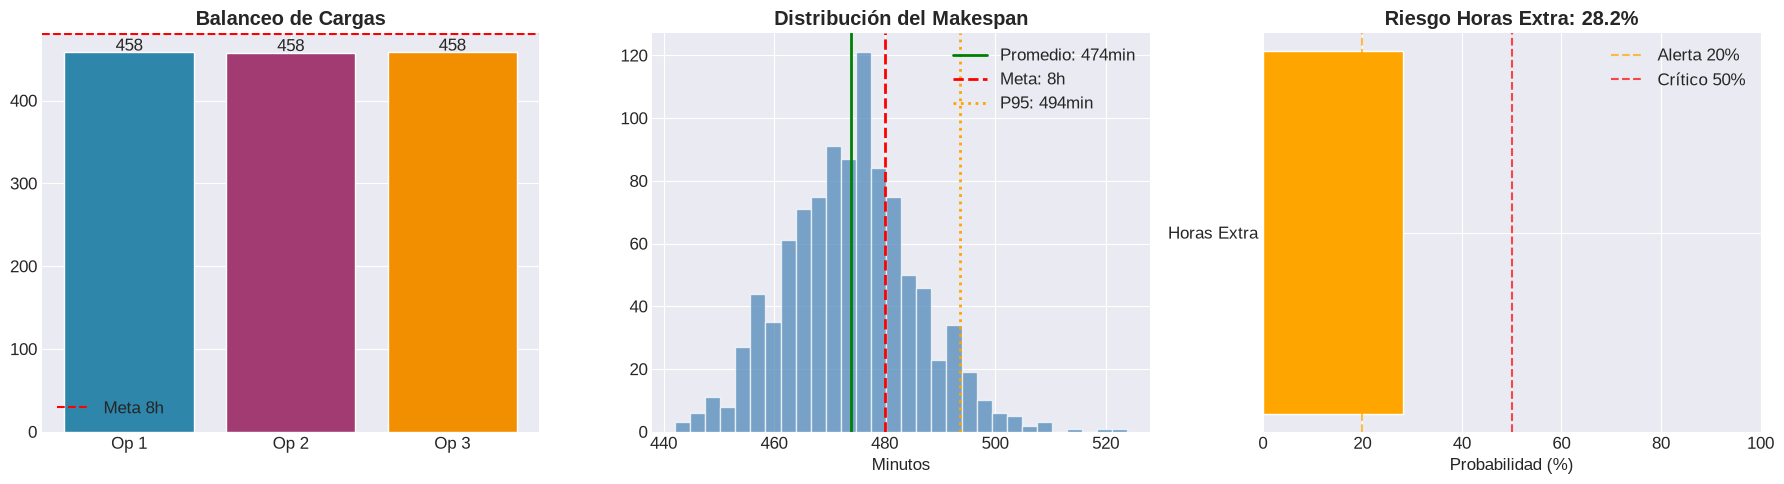

Gráficos guardados en /home/migue07/Documents/Proyectos/optimizacion_despachos/reports/figures


ESCENARIO 2: Omitido
   No se configuraron eventos. Solo se ejecutó el Escenario 1.
   Para ver el impacto de eventos, configura MIS_EVENTOS.


COMPARATIVA DE ESCENARIOS

Escenario                                Makespan P95    Prob. H.Extra   Veredicto                
-----------------------------------------------------------------------------------------------
Línea Base (sin eventos)                    494 min       28.2%         REQUIERE ATENCIÓN        

Configura MIS_EVENTOS para ver el impacto de reuniones e imprevistos.


RECOMENDACIONES PARA LA JORNADA

LA JORNADA REQUIERE ATENCIÓN con 3 operadores
   Déficit estimado: 14 min (0.2h)
   Probabilidad de horas extra: 28.2%

   ACCIONES RECOMENDADAS:
   1. Agregar 4º operador
   2. Reducir ~0 rutas del pool
   3. Adelantar inicio en 4 min

PLAN DE CONTINGENCIA:
   Probabilidad de necesitar rebalanceo: 28.2%
   Recomendación: MONITOREA

In [25]:
# Configuración y ejecución de Jornada

# Rutas a despachar según planificación

MIS_RUTAS_REALES = [
    213, 252, 253, 254, 255, 256, 257, 258, 260, 261, 263, 264, 266, 211, 209,
    207, 201, 1259, 9389, 9388, 9387, 9386, 9385, 9384, 315, 313, 312, 311, 310,
    309, 308, 307, 306, 304, 303, 301, 9435, 9426, 9425, 9424, 9422, 9419, 9390,
    9371, 9370, 9355, 9353, 9345, 9344, 9340, 9339, 9337, 9326, 9320, 9312, 9311,
    9310, 9305, 8256, 8003, 8002, 7739, 7733, 7729, 7693, 7692, 7690, 7681, 7680,
    7677, 7675, 7663, 7659, 7651, 7649, 7643, 7642, 7640, 7637, 7634, 7631, 7627, 
    7626, 7624, 7604, 7601, 9383    
]

# Parámetros de jornada

MIS_OPERADORES = 3       
MI_HORA_INICIO = 15        # Formato 24 horas
MI_META_HORAS = 8          # Jornada objetivo en horas
MIS_SIMULACIONES = 1000    

# Eventos del día

MIS_EVENTOS = {
    # EJEMPLO: Reunión programada (descomenta y modifica):
    # 'reunion_inicio': {
    #     'hora': '15:30',       # 3:30 PM
    #     'duracion': 15,        # 15 minutos
    #     'afecta': 'todos',     # 'todos', 'aleatorio', o número (1, 2, 3)
    #     'tipo': 'programado'
    # },
    
    # EJEMPLO: Imprevisto aleatorio (descomenta y modifica):
    # 'descarga_urgente': {
    #     'probabilidad': 0.20,  # 20% de probabilidad por hora
    #     'duracion_media': 20,  # Duración promedio
    #     'duracion_std': 10,    # Desviación estándar
    #     'afecta': 'aleatorio', # Afecta a un operador al azar
    #     'tipo': 'aleatorio'
    # }
}

# Verificación de configuración

print("CONFIGURACIÓN DE LA JORNADA")

print(f"Rutas a despachar: {len(MIS_RUTAS_REALES)}")
print(f"Operadores: {MIS_OPERADORES}")
print(f"Hora de inicio: {MI_HORA_INICIO}:00")
print(f"Meta: {MI_META_HORAS} horas")
print(f"Eventos configurados: {len(MIS_EVENTOS)}")
print(f"Simulaciones: {MIS_SIMULACIONES}")

# ESCENARIO 1: Línea Base (sin eventos)

print("\n")
print("ESCENARIO 1: Línea Base (sin eventos)")
print("   Evalúa la jornada en condiciones ideales, solo con variabilidad natural.")

plan_base = PlanificadorJornada()

plan_base.configurar(
    rutas=MIS_RUTAS_REALES,
    n_operadores=MIS_OPERADORES,
    eventos_dia={}, 
    hora_inicio=MI_HORA_INICIO,
    meta_horas=MI_META_HORAS,
    n_simulaciones=MIS_SIMULACIONES,
    seed=42
)

plan_base.ejecutar()

# Mostrar asignación detallada
print("\n")
print("ASIGNACIÓN DE RUTAS POR OPERADOR")

df_asig = plan_base.resultado_opt['df_asignacion']
for op in sorted(df_asig['operador'].unique()):
    rutas_op = df_asig[df_asig['operador'] == op].sort_values('tiempo_estimado', ascending=False)
    carga = rutas_op['tiempo_estimado'].sum()
    ids = rutas_op['id_ruta'].tolist()
    
    print(f"\nOperador {op}: {len(rutas_op)} rutas | {carga:.0f} min ({carga/60:.1f}h)")
    print(f"   IDs: {ids}")
    
plan_base.mostrar_diagnostico()
plan_base.graficar_resultados()

# ESCENARIO 2: Con Eventos del Día

if MIS_EVENTOS:
    print("\n")
    print("ESCENARIO 2: Con Eventos del Día")
    print("   Evalúa el impacto de reuniones e imprevistos configurados.")

    plan_eventos = PlanificadorJornada()

    plan_eventos.configurar(
        rutas=MIS_RUTAS_REALES,
        n_operadores=MIS_OPERADORES,
        eventos_dia=MIS_EVENTOS,
        hora_inicio=MI_HORA_INICIO,
        meta_horas=MI_META_HORAS,
        n_simulaciones=MIS_SIMULACIONES,
        seed=42
    )

    plan_eventos.ejecutar()
    plan_eventos.mostrar_diagnostico()
    plan_eventos.graficar_resultados()
else:
    print("\n")
    print("ESCENARIO 2: Omitido")
    print("="*80)
    print("   No se configuraron eventos. Solo se ejecutó el Escenario 1.")
    print("   Para ver el impacto de eventos, configura MIS_EVENTOS.")
    plan_eventos = None

# COMPARATIVA FINAL

print("\n")
print("COMPARATIVA DE ESCENARIOS")

if plan_eventos and plan_eventos.diagnostico_completo:
    print(f"\n{'Escenario':<40} {'Makespan P95':<15} {'Prob. H.Extra':<15} {'Impacto':<20} {'Veredicto':<25}")
    print("-"*115)
    
    d1 = plan_base.diagnostico_completo
    d2 = plan_eventos.diagnostico_completo
    
    makespan1 = d1['simulacion']['p95_makespan']
    makespan2 = d2['simulacion']['p95_makespan']
    impacto = makespan2 - makespan1
    
    print(f"{'Línea Base (sin eventos)':<40} {makespan1:>6.0f} min      {d1['simulacion']['prob_horas_extra']:>5.1f}%         {'--':<20} {d1['viabilidad']['estado']:<25}")
    print(f"{'Con Eventos del Día':<40} {makespan2:>6.0f} min      {d2['simulacion']['prob_horas_extra']:>5.1f}%         {'+' + str(int(impacto)) + ' min':<20} {d2['viabilidad']['estado']:<25}")
    
    print(f"\nImpacto de los eventos: +{impacto:.0f} min ({impacto/60:.1f}h) adicionales en el makespan P95")
else:
    print(f"\n{'Escenario':<40} {'Makespan P95':<15} {'Prob. H.Extra':<15} {'Veredicto':<25}")
    print("-"*95)
    
    d1 = plan_base.diagnostico_completo
    makespan1 = d1['simulacion']['p95_makespan']
    
    print(f"{'Línea Base (sin eventos)':<40} {makespan1:>6.0f} min      {d1['simulacion']['prob_horas_extra']:>5.1f}%         {d1['viabilidad']['estado']:<25}")
    print(f"\nConfigura MIS_EVENTOS para ver el impacto de reuniones e imprevistos.")

# RECOMENDACIÓN FINAL

print("\n")
print("RECOMENDACIONES PARA LA JORNADA")

d = plan_base.diagnostico_completo
v = d['viabilidad']
r = d['resumen']
reb = d['rebalanceo']

if v['viable']:
    print(f"\nLA JORNADA ES VIABLE con {MIS_OPERADORES} operadores")
    print(f"   Makespan esperado (promedio): {r['makespan_simulado']:.0f} min ({r['makespan_simulado']/60:.1f}h)")
    print(f"   Makespan P95 (peor caso): {r['makespan_p95']:.0f} min ({r['makespan_p95']/60:.1f}h)")
    print(f"   Holgura: {v['holgura_min']:.0f} min ({v['holgura_horas']:.1f}h)")
    print(f"   Probabilidad de horas extra: {r['prob_horas_extra']:.1f}%")
    
    if v['nivel'] == 'AJUSTADA':
        print(f"\nLa holgura es pequeña. Cualquier imprevisto podría generar horas extra.")
    elif v['nivel'] == 'CÓMODA':
        print(f"\nHay margen suficiente para absorber imprevistos menores.")
else:
    deficit = abs(v['holgura_min'])
    print(f"\nLA JORNADA REQUIERE ATENCIÓN con {MIS_OPERADORES} operadores")
    print(f"   Déficit estimado: {deficit:.0f} min ({deficit/60:.1f}h)")
    print(f"   Probabilidad de horas extra: {r['prob_horas_extra']:.1f}%")
    print(f"\n   ACCIONES RECOMENDADAS:")
    print(f"   1. Agregar {MIS_OPERADORES + 1}º operador")
    print(f"   2. Reducir ~{int(deficit/15)} rutas del pool")
    print(f"   3. Adelantar inicio en {int(deficit/MIS_OPERADORES)} min")

# Análisis de rebalanceo
if reb.get('probabilidad_rebalanceo_global', 0) > 20:
    print(f"\nPLAN DE CONTINGENCIA:")
    print(f"   Probabilidad de necesitar rebalanceo: {reb['probabilidad_rebalanceo_global']:.1f}%")
    print(f"   Recomendación: {reb.get('recomendacion', 'N/A')}")
    if reb.get('momentos_criticos'):
        for mc in reb['momentos_criticos'][:2]:
            hora_real = MI_HORA_INICIO + mc['hora_jornada']
            print(f"Monitorear a las {hora_real}:00 hrs ({mc['probabilidad_retraso']:.0f}% prob. retraso)")

print("\n")
print("DIAGNÓSTICO COMPLETADO")

## 8. Validación Retrospectiva

### Objetivo

Comparar la simulación contra una jornada real ya ocurrida para medir 
la precisión del sistema y calibrar la confianza en las predicciones.

### ¿Qué evalúa?

| Métrica | Descripción | Interpretación |
|---------|-------------|----------------|
| **Error absoluto** | Diferencia entre makespan simulado y duración real | < 30 min = bueno |
| **Error porcentual** | Error relativo a la duración real | < 10% = excelente |
| **Cobertura** | ¿La duración real cayó dentro del rango P5-P95? | Sí = modelo confiable |

### Metodología

1. Cargar las rutas reales de una fecha específica del histórico
2. Predecir tiempos con el Random Forest
3. Optimizar asignación con PuLP
4. Simular con Monte Carlo
5. Comparar makespan simulado vs duración real registrada



FECHAS DISPONIBLES EN TU HISTÓRICO

Cargando modelos de la Fase 2...
Scaler cargado
Modelo Random Forest cargado
Metadatos cargados
MAE del modelo: 2.8564407061768113 min

Datos históricos cargados: 584 registros
   Columnas disponibles: ['fecha', 'id_ruta', 'hora_inicio_jornada', 'hora_fin_jornada', 'tiempo_inicio_ruta', 'tiempo_fin_ruta', 'tiempo_total_jornada', 'cant_productos', 'valor_ruta', 'tiempo_inicio_ruta_delta', 'tiempo_fin_ruta_delta', 'tiempo_preparacion_minutos', 'velocidad_despacho', 'mi_dificultad', 'semana', 'mes', 'horas_jornada', 'productividad_jornada', 'dia_semana', 'dificultad_cuartiles']
Columnas requeridas verificadas
Total de fechas registradas: 27
Últimas 5: ['2026-07-11', '2026-07-14', '2026-07-15', '2026-07-16', '2026-07-17']


Ejecutando validación con tu fecha más reciente...


VALIDACIÓN RETROSPECTIVA - Jornada Personal
Fecha evaluada: 2026-07-17

Cargando modelos de la Fase 2...
Scaler cargado
Modelo Random Forest cargado
Metadatos cargados
MAE del mod

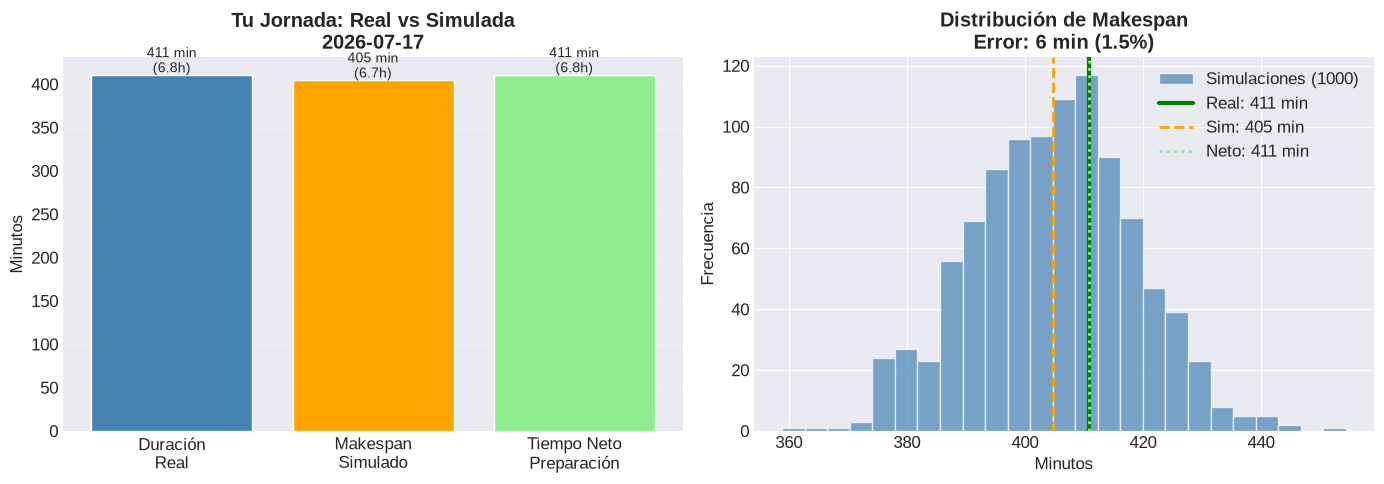


Gráfico guardado en: /home/migue07/Documents/Proyectos/optimizacion_despachos/reports/figures

ESUMEN DE VALIDACIÓN:
   Fecha: 2026-07-17
   Tus rutas: 21
   Duración real: 411 min (6.8h)
   Makespan simulado: 405 min (6.7h)
   Error: 6 min (1.5%)
   Precisión: BUENA
   Cobertura P5-P95: SÍ

   Precisión sobre tiempo neto (sin pausas):
   Error neto: 6 min (1.5%)


In [30]:
# Validación retrospectiva

def validar_jornada_personal(fecha_prueba, n_iteraciones=500, seed=42):
    """
    Compara la simulación contra lo que realmente tomó la jornada.
    
    Como el dataset solo contiene mis rutas,
    esta validación compara:
      - Duración real: de hora_inicio_jornada a hora_fin_jornada
      - Simulación: makespan con 1 operario para las rutas de ese día
    
    Args:
        fecha_prueba: Fecha a evaluar (debe existir en tu CSV)
        n_iteraciones: Iteraciones Monte Carlo
        seed: Semilla para reproducibilidad
    
    Returns:
        dict con comparativa detallada
    """
    
    print("\n")
    print(f"VALIDACIÓN RETROSPECTIVA - Jornada Personal")
    print(f"Fecha evaluada: {fecha_prueba}")
    
    # 1. Cargar datos y filtrar por fecha
    cargador = CargadorDatos()
    df_historico = cargador.df_historico
    
    if 'fecha' not in df_historico.columns:
        print("ERROR: El dataset no tiene columna 'fecha'.")
        return None
    
    df_dia = df_historico[df_historico['fecha'] == fecha_prueba].copy()
    
    if len(df_dia) == 0:
        fechas_disponibles = sorted(df_historico['fecha'].unique())
        print(f"Fecha '{fecha_prueba}' no encontrada.")
        print(f"Fechas disponibles (últimas 10): {fechas_disponibles[-10:]}")
        return None
    
    print(f"\nTus rutas ese día: {len(df_dia)}")
    
    # 2. Extraer duración real de TU jornada
    hora_inicio_real = None
    hora_fin_real = None
    duracion_real = None
    horas_jornada = None
    
    # Opción A: Usar columna 'horas_jornada' (ya calculada en Fase 1)
    if 'horas_jornada' in df_dia.columns:
        horas_jornada = df_dia['horas_jornada'].iloc[0]
        duracion_real = horas_jornada * 60  # Convertir horas a minutos
        print(f"Duración real (de columna horas_jornada): {duracion_real:.0f} min ({duracion_real/60:.2f} horas)")
    
    # Opción B: Calcular desde hora_inicio y hora_fin (respaldo)
    if duracion_real is None:
        if 'hora_inicio_jornada' in df_dia.columns:
            hora_inicio_real = str(df_dia['hora_inicio_jornada'].iloc[0])
        if 'hora_fin_jornada' in df_dia.columns:
            hora_fin_real = str(df_dia['hora_fin_jornada'].iloc[0])
        
        if hora_inicio_real and hora_fin_real:
            try:
                # Parsear formato HH:MM:SS
                h_i, m_i, s_i = map(int, hora_inicio_real.split(':'))
                h_f, m_f, s_f = map(int, hora_fin_real.split(':'))
                
                minutos_inicio = h_i * 60 + m_i
                minutos_fin = h_f * 60 + m_f
                
                duracion_real = minutos_fin - minutos_inicio
                if duracion_real <= 0:
                    duracion_real += 24 * 60  # Cruzó medianoche
                
                print(f"Hora inicio: {hora_inicio_real}")
                print(f"Hora fin: {hora_fin_real}")
                print(f"Duración real (calculada): {duracion_real:.0f} min ({duracion_real/60:.2f} horas)")
            except Exception as e:
                print(f"Error al parsear horas: {e}")
    
    if duracion_real is None or duracion_real <= 0:
        print("No se pudo calcular la duración real.")
        return None
    
    # También obtener el tiempo total de preparación (suma de tiempos por ruta)
    tiempo_total_real = None
    if 'tiempo_preparacion_minutos' in df_dia.columns:
        tiempo_total_real = df_dia['tiempo_preparacion_minutos'].sum()
        print(f"Tiempo neto de preparación (suma rutas): {tiempo_total_real:.0f} min ({tiempo_total_real/60:.2f} horas)")
        if duracion_real > tiempo_total_real:
            pausas = duracion_real - tiempo_total_real
            print(f"Tiempo no productivo (pausas, interrupciones): {pausas:.0f} min ({pausas/60:.2f} horas)")
    
    # 3. Ejecutar planificación con 1 SOLO OPERADOR (tú)
    rutas_ids = df_dia['id_ruta'].tolist()
    
    # Extraer hora de inicio para la simulación
    if hora_inicio_real:
        h_i = int(hora_inicio_real.split(':')[0])
    elif 'hora_inicio_jornada' in df_dia.columns:
        h_i = int(str(df_dia['hora_inicio_jornada'].iloc[0]).split(':')[0])
    else:
        h_i = 7
    
    print(f"\nSimulando con mi operación y las {len(rutas_ids)} rutas...")
    
    plan = PlanificadorJornada()
    plan.configurar(
        rutas=rutas_ids,
        n_operadores=1,
        eventos_dia={},
        hora_inicio=h_i,
        meta_horas=8,
        n_simulaciones=n_iteraciones,
        seed=seed
    )
    plan.ejecutar()
    
    # 4. Extraer resultados simulados
    makespan_simulado = plan.resultado_sim['mean_makespan']
    makespan_p95 = plan.resultado_sim['p95_makespan']
    makespan_p05 = np.percentile(plan.resultado_sim['makespans'], 5)
    std_makespan = plan.resultado_sim['std_makespan']
    
    # 5. Calcular error contra la duración real
    error_abs = abs(makespan_simulado - duracion_real)
    error_pct = (error_abs / duracion_real) * 100 if duracion_real > 0 else 0
    
    # También comparar contra el tiempo neto (sin pausas)
    if tiempo_total_real:
        error_abs_neto = abs(makespan_simulado - tiempo_total_real)
        error_pct_neto = (error_abs_neto / tiempo_total_real) * 100 if tiempo_total_real > 0 else 0
    else:
        error_abs_neto = None
        error_pct_neto = None
    
    # 6. Verificar cobertura
    dentro_rango = makespan_p05 <= duracion_real <= makespan_p95
    
    # 7. Evaluación cualitativa
    if error_pct < 10:
        precision = "BUENA"
    elif error_pct < 20:
        precision = "ACEPTABLE"
    else:
        precision = "MEJORABLE (posiblemente hay pausas no modeladas)"
    
    # 8. Mostrar comparativa
    print("\n")
    print("COMPARATIVA: SIMULADO vs REAL (Jornada Personal)")
    
    print(f"\nDATOS REALES ({fecha_prueba}):")
    print(f"   Tus rutas despachadas: {len(df_dia)}")
    print(f"   Duración real (reloj): {duracion_real:.0f} min ({duracion_real/60:.1f}h)")
    if tiempo_total_real:
        print(f"   Tiempo neto preparación: {tiempo_total_real:.0f} min ({tiempo_total_real/60:.1f}h)")
        pausas = duracion_real - tiempo_total_real
        print(f"   Pausas/interrupciones: {pausas:.0f} min ({pausas/60:.1f}h)")
    
    print(f"\nRESULTADOS SIMULADOS:")
    print(f"   Makespan promedio: {makespan_simulado:.0f} min ({makespan_simulado/60:.1f}h)")
    print(f"   Makespan P95: {makespan_p95:.0f} min ({makespan_p95/60:.1f}h)")
    print(f"   Rango P5-P95: [{makespan_p05:.0f} - {makespan_p95:.0f}] min")
    print(f"   Desviación std: {std_makespan:.0f} min")
    
    print(f"\nPRECISIÓN DEL MODELO:")
    print(f"   vs Duración real (reloj):")
    print(f"      Error: {error_abs:.0f} min ({error_pct:.1f}%) → {precision}")
    print(f"      ¿Realidad dentro del rango?: {'SÍ ✓' if dentro_rango else 'NO ✗'}")
    
    if tiempo_total_real and error_abs_neto is not None:
        print(f"   vs Tiempo neto (sin pausas):")
        print(f"      Error: {error_abs_neto:.0f} min ({error_pct_neto:.1f}%)")
        if error_pct_neto < 5:
            print(f"      → El modelo predice muy bien el tiempo de preparación pura")
        elif error_pct_neto < 15:
            print(f"      → Precisión aceptable considerando la variabilidad natural")
        else:
            print(f"      → Hay diferencias significativas. Revisar calidad de predicciones")
    
    if not dentro_rango:
        if duracion_real < makespan_p05:
            print(f"\n   → La jornada real fue MÁS RÁPIDA que lo simulado")
        else:
            print(f"\n   → La jornada real fue MÁS LENTA que lo simulado")
            print(f"   → Posibles causas: pausas no registradas, fatiga, interrupciones")
    
    # 9. Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Barras comparativas
    ax1 = axes[0]
    categorias = ['Duración\nReal']
    valores = [duracion_real]
    colores = ['steelblue']
    
    categorias.append('Makespan\nSimulado')
    valores.append(makespan_simulado)
    colores.append('orange')
    
    if tiempo_total_real:
        categorias.append('Tiempo Neto\nPreparación')
        valores.append(tiempo_total_real)
        colores.append('lightgreen')
    
    bars = ax1.bar(categorias, valores, color=colores, edgecolor='white')
    for bar, val in zip(bars, valores):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f'{val:.0f} min\n({val/60:.1f}h)', ha='center', fontsize=10)
    
    ax1.set_ylabel('Minutos')
    ax1.set_title(f'Tu Jornada: Real vs Simulada\n{fecha_prueba}', fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    
    # Gráfico 2: Distribución del makespan simulado
    ax2 = axes[1]
    ax2.hist(plan.resultado_sim['makespans'], bins=25, color='steelblue',
             edgecolor='white', alpha=0.7, label=f'Simulaciones ({n_iteraciones})')
    ax2.axvline(x=duracion_real, color='green', linewidth=3,
                label=f'Real: {duracion_real:.0f} min')
    ax2.axvline(x=makespan_simulado, color='orange', linewidth=2,
                linestyle='--', label=f'Sim: {makespan_simulado:.0f} min')
    if tiempo_total_real:
        ax2.axvline(x=tiempo_total_real, color='lightgreen', linewidth=2,
                    linestyle=':', label=f'Neto: {tiempo_total_real:.0f} min')
    
    ax2.set_xlabel('Minutos')
    ax2.set_ylabel('Frecuencia')
    ax2.set_title(f'Distribución de Makespan\nError: {error_abs:.0f} min ({error_pct:.1f}%)',
                  fontweight='bold')
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS_PATH, f'validacion_personal_{fecha_prueba}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nGráfico guardado en: {REPORTS_PATH}")
    print("="*70)
    
    return {
        'fecha': fecha_prueba,
        'n_rutas': len(df_dia),
        'duracion_real_min': duracion_real,
        'tiempo_neto_real_min': tiempo_total_real,
        'makespan_simulado_min': makespan_simulado,
        'makespan_p95_min': makespan_p95,
        'error_abs_min': error_abs,
        'error_pct': error_pct,
        'error_abs_neto_min': error_abs_neto,
        'error_pct_neto': error_pct_neto,
        'precision': precision,
        'cobertura': dentro_rango,
        'planificador': plan
    }


# Listar fechas disponibles

print("\n")
print("FECHAS DISPONIBLES EN TU HISTÓRICO")
cargador_temp = CargadorDatos()
if 'fecha' in cargador_temp.df_historico.columns:
    fechas = sorted(cargador_temp.df_historico['fecha'].unique())
    print(f"Total de fechas registradas: {len(fechas)}")
    print(f"Últimas 5: {fechas[-5:]}")
else:
    print("No se encontró columna 'fecha' en los datos.")
    fechas = []


# Validar con la fecha más reciente

print("\n")
print("Ejecutando validación con tu fecha más reciente...")
fecha_reciente = fechas[-1] if len(fechas) > 0 else None

if fecha_reciente:
    resultado_val = validar_jornada_personal(
        fecha_prueba=fecha_reciente,
        n_iteraciones=1000,  # Para mejorar la precisión de la simulación
        seed=42
    )
    
    if resultado_val:
        print(f"\nESUMEN DE VALIDACIÓN:")
        print(f"   Fecha: {resultado_val['fecha']}")
        print(f"   Tus rutas: {resultado_val['n_rutas']}")
        print(f"   Duración real: {resultado_val['duracion_real_min']:.0f} min ({resultado_val['duracion_real_min']/60:.1f}h)")
        print(f"   Makespan simulado: {resultado_val['makespan_simulado_min']:.0f} min ({resultado_val['makespan_simulado_min']/60:.1f}h)")
        print(f"   Error: {resultado_val['error_abs_min']:.0f} min ({resultado_val['error_pct']:.1f}%)")
        print(f"   Precisión: {resultado_val['precision']}")
        print(f"   Cobertura P5-P95: {'SÍ' if resultado_val['cobertura'] else 'NO'}")
        
        if resultado_val['error_abs_neto_min'] is not None:
            print(f"\n   Precisión sobre tiempo neto (sin pausas):")
            print(f"   Error neto: {resultado_val['error_abs_neto_min']:.0f} min ({resultado_val['error_pct_neto']:.1f}%)")
else:
    print("No se encontraron fechas para validar.")
